# Importing The necessary libraries

In [1]:
import pandas as pd; 
import matplotlib.pyplot as plt;
import numpy as np ;

# Importing the QVI_Data file

In [2]:
qvi_data = pd.read_csv("C:/Users/user/OneDrive - Hetauda School of Management and Social Sciences/Desktop/Data Analysis/Projects/Project III/Raw Data & Problems/QVI_data_web.csv");
qvi_data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,10/17/2018,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,9/16/2018,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,3/7/2019,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,3/8/2019,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,11/2/2018,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


# Adding new column as YEARMONTH

In [3]:
qvi_data["DATE"] = pd.to_datetime(qvi_data["DATE"]);
qvi_data["YEARMONTH"] = qvi_data["DATE"].dt.year * 100 + qvi_data["DATE"].dt.month ;
qvi_data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811


# Defining Metrics

In [4]:
measureOverTime = (qvi_data.groupby(["STORE_NBR", "YEARMONTH"]).agg(
    totSales=("TOT_SALES","sum"),
    ntransactions=("TXN_ID","nunique"),
    ncustomers=("LYLTY_CARD_NBR","nunique"),
    totalQty=("PROD_QTY","sum")
).reset_index()
);

measureOverTime["nTxnPerCust"] = (measureOverTime["ntransactions"] / measureOverTime["ncustomers"]);

measureOverTime["nChipsPerTxn"] = (measureOverTime["totalQty"]/measureOverTime["ntransactions"]);

measureOverTime["avgPricePerUnit"] = (measureOverTime["totSales"]/measureOverTime["totalQty"]) ;
measureOverTime

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,52,49,62,1.061224,1.192308,3.337097
1,1,201808,176.1,43,42,54,1.023810,1.255814,3.261111
2,1,201809,278.8,62,59,75,1.050847,1.209677,3.717333
3,1,201810,188.1,45,44,58,1.022727,1.288889,3.243103
4,1,201811,192.6,47,46,57,1.021739,1.212766,3.378947
...,...,...,...,...,...,...,...,...,...
3164,272,201902,395.5,48,45,91,1.066667,1.895833,4.346154
3165,272,201903,442.3,53,50,101,1.060000,1.905660,4.379208
3166,272,201904,445.1,55,54,105,1.018519,1.909091,4.239048
3167,272,201905,314.6,40,34,71,1.176471,1.775000,4.430986


# Filtering Pre Trial Months

In [5]:
n_pretrial_months = measureOverTime[
    measureOverTime["YEARMONTH"] < 201902
]["YEARMONTH"].nunique()

print("Number of pre-trial months:", n_pretrial_months)

preTrialCounts = (
    measureOverTime[measureOverTime["YEARMONTH"] < 201902]
    .groupby("STORE_NBR")["YEARMONTH"]
    .nunique()
    .reset_index(name="month_count")
) ;

storesWithFullObs = preTrialCounts[
    preTrialCounts["month_count"] == n_pretrial_months
]["STORE_NBR"]

preTrialMeasures = measureOverTime[
    (measureOverTime["YEARMONTH"] < 201902) &
    (measureOverTime["STORE_NBR"].isin(storesWithFullObs))
]

preTrialMeasures


Number of pre-trial months: 7


,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,52,49,62,1.061224,1.192308,3.337097
1,1,201808,176.1,43,42,54,1.023810,1.255814,3.261111
2,1,201809,278.8,62,59,75,1.050847,1.209677,3.717333
3,1,201810,188.1,45,44,58,1.022727,1.288889,3.243103
4,1,201811,192.6,47,46,57,1.021739,1.212766,3.378947
...,...,...,...,...,...,...,...,...,...
3159,272,201809,304.7,36,32,71,1.125000,1.972222,4.291549
3160,272,201810,430.6,50,44,99,1.136364,1.980000,4.349495
3161,272,201811,376.2,45,41,87,1.097561,1.933333,4.324138
3162,272,201812,403.9,47,47,89,1.000000,1.893617,4.538202


# Calculation of Correlation of store 77,86 & 88

In [6]:
def calculate_correlation(inputTable, metricCol, storeComparison):
    
    trial_store = inputTable[inputTable["STORE_NBR"] == storeComparison]
    
    storeNumbers = inputTable["STORE_NBR"].unique()
    storeNumbers = storeNumbers[storeNumbers != storeComparison]
    
    results = []
    
    for store in storeNumbers:
        
        control_store = inputTable[inputTable["STORE_NBR"] == store]
        
        merged = trial_store.merge(
            control_store,
            on="YEARMONTH",
            suffixes=("_trial", "_control")
        )
        
        # Calculate correlation
        corr = merged[f"{metricCol}_trial"].corr(
            merged[f"{metricCol}_control"]
        )
        
        results.append({
            "Store1": storeComparison,
            "Store2": store,
            "corr_measure": corr
        })
    
    return pd.DataFrame(results)

corr_sales_77 = calculate_correlation(
    preTrialMeasures,
    "totSales",
    77
)
corr_sales_84 = calculate_correlation(
    preTrialMeasures,
    "totSales",
    84
)
corr_sales_88 = calculate_correlation(
    preTrialMeasures,
    "totSales",
    88
)
print(corr_sales_77.sort_values("corr_measure", ascending=False).head())
print()
print(corr_sales_84.sort_values("corr_measure", ascending=False).head())
print()
print(corr_sales_88.sort_values("corr_measure", ascending=False))

     Store1  Store2  corr_measure
67       77      71      0.914106
220      77     233      0.903774
110      77     119      0.867664
15       77      17      0.842668
2        77       3      0.806644

     Store1  Store2  corr_measure
159      84     168      0.953761
148      84     157      0.833558
187      84     197      0.818319
2        84       3      0.804775
189      84     199      0.799090

     Store1  Store2  corr_measure
150      88     159      0.903186
194      88     204      0.885774
125      88     134      0.864293
0        88       1      0.813636
239      88     253      0.811838
..      ...     ...           ...
258      88     272     -0.772772
21       88      23     -0.801652
7        88       8     -0.816296
44       88      48     -0.857142
217      88     230     -0.908883

[259 rows x 3 columns]


# <b style="color:Blue"> For trial store 77 </b>

# Calculating Correlation and Magnitudes

In [7]:
def calculate_magnitude_distance(inputTable, metricCol, storeComparison):
    
    trial_store = inputTable[inputTable["STORE_NBR"] == storeComparison]
    
    storeNumbers = inputTable["STORE_NBR"].unique()
    storeNumbers = storeNumbers[storeNumbers != storeComparison]
    
    results = []
    
    for store in storeNumbers:
        
        control_store = inputTable[inputTable["STORE_NBR"] == store]
        
        merged = trial_store.merge(
            control_store,
            on="YEARMONTH",
            suffixes=("_trial", "_control")
        )
        
        # Absolute difference
        merged["measure"] = abs(
            merged[f"{metricCol}_trial"] -
            merged[f"{metricCol}_control"]
        )
        
        # Min-Max scaling per month
        min_dist = merged["measure"].min()
        max_dist = merged["measure"].max()
        
        if max_dist - min_dist == 0:
            merged["magnitudeMeasure"] = 1
        else:
            merged["magnitudeMeasure"] = 1 - (
                (merged["measure"] - min_dist) /
                (max_dist - min_dist)
            )
        
        final_score = merged["magnitudeMeasure"].mean()
        
        results.append({
            "Store1": storeComparison,
            "Store2": store,
            "mag_measure": final_score
        })
    
    return pd.DataFrame(results)

trial_store = 77

# Correlation
corr_nSales = calculate_correlation(preTrialMeasures, "totSales", trial_store)
corr_nCustomers = calculate_correlation(preTrialMeasures, "ncustomers", trial_store)

# Magnitude
magnitude_nSales = calculate_magnitude_distance(preTrialMeasures, "totSales", trial_store)
magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures, "ncustomers", trial_store)

combined = (
    corr_nSales.rename(columns={"corr_measure": "corr_sales"})
    .merge(
        corr_nCustomers.rename(columns={"corr_measure": "corr_customers"}),
        on=["Store1", "Store2"]
    )
    .merge(
        magnitude_nSales,
        on=["Store1", "Store2"]
    )
    .merge(
        magnitude_nCustomers,
        on=["Store1", "Store2"],
        suffixes=("_sales", "_customers")
    )
)

combined["final_score"] = (
    combined["corr_sales"] +
    combined["corr_customers"] +
    combined["mag_measure_sales"] +
    combined["mag_measure_customers"]
) / 4

combined.sort_values("final_score", ascending=False)

,Store1,Store2,corr_sales,corr_customers,mag_measure_sales,mag_measure_customers,final_score
220,77,233,0.903774,0.990358,0.490806,0.642857,0.756949
67,77,71,0.914106,0.754817,0.664887,0.571429,0.726310
78,77,84,0.684348,0.858571,0.629596,0.571429,0.685986
110,77,119,0.867664,0.983267,0.404428,0.476190,0.682887
107,77,115,0.689159,0.718882,0.727536,0.571429,0.676751
...,...,...,...,...,...,...,...
160,77,169,-0.630112,-0.666391,0.473506,0.523810,-0.074797
229,77,242,-0.692664,-0.643351,0.449028,0.550000,-0.084247
177,77,186,-0.820214,-0.635966,0.562601,0.521429,-0.093037
94,77,102,-0.550834,-0.652527,0.346357,0.414286,-0.110680


# Combining magnitude and correlation

In [8]:
corr_weight = 0.5

score_nSales = (
    corr_nSales
    .merge(magnitude_nSales, on=["Store1", "Store2"])
)

score_nSales["scoreNSales"] = (
    corr_weight * score_nSales["corr_measure"] +
    (1 - corr_weight) * score_nSales["mag_measure"]
)

score_nCustomers = (
    corr_nCustomers
    .merge(magnitude_nCustomers, on=["Store1", "Store2"])
)

score_nCustomers["scoreNCust"] = (
    corr_weight * score_nCustomers["corr_measure"] +
    (1 - corr_weight) * score_nCustomers["mag_measure"]
)

score_Control = (
    score_nSales[["Store1", "Store2", "scoreNSales"]]
    .merge(
        score_nCustomers[["Store1", "Store2", "scoreNCust"]],
        on=["Store1", "Store2"]
    )
)

score_Control["finalControlScore"] = (
    0.5 * score_Control["scoreNSales"] +
    0.5 * score_Control["scoreNCust"]
)

score_Control_sorted = score_Control.sort_values(
    "finalControlScore",
    ascending=False
)

score_Control_sorted.head()

control_store = score_Control_sorted.iloc[0]["Store2"]
control_store

np.float64(233.0)

# Visual check of TotalSales

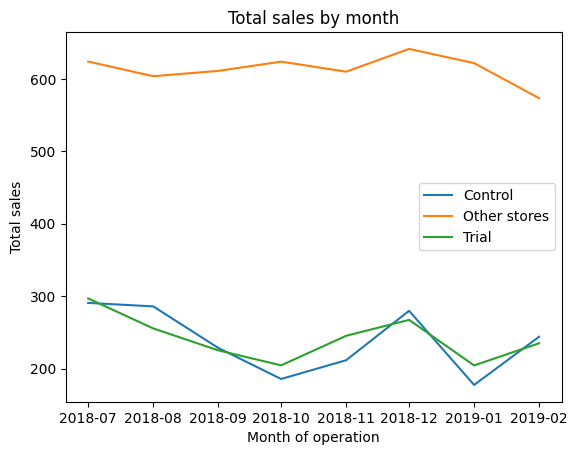

In [9]:
trial_store = 77   
control_store = control_store  

measureOverTimeSales = measureOverTime.copy()

measureOverTimeSales["Store_type"] = np.where(
    measureOverTimeSales["STORE_NBR"] == trial_store,
    "Trial",
    np.where(
        measureOverTimeSales["STORE_NBR"] == control_store,
        "Control",
        "Other stores"
    )
)

pastSales = (
    measureOverTimeSales
    .groupby(["YEARMONTH", "Store_type"])["totSales"]
    .mean()
    .reset_index()
)

pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str) + "01",
    format="%Y%m%d"
)

pastSales = pastSales[pastSales["YEARMONTH"] < 201903]

plt.figure()
for label in pastSales["Store_type"].unique():
    subset = pastSales[pastSales["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"],  label=label)

plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.legend()
plt.title("Total sales by month")
plt.show()

# Visual check of No of Customers

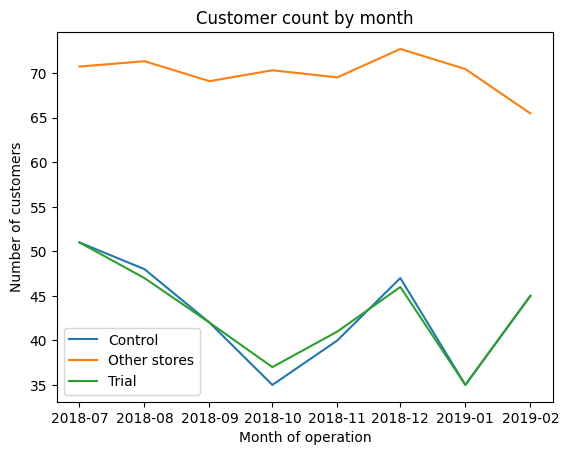

In [10]:
measureOverTimeCusts = measureOverTime.copy()

measureOverTimeCusts["Store_type"] = np.where(
    measureOverTimeCusts["STORE_NBR"] == trial_store,
    "Trial",
    np.where(
        measureOverTimeCusts["STORE_NBR"] == control_store,
        "Control",
        "Other stores"
    )
)

measureOverTimeCusts

pastCustomers = (
    measureOverTimeCusts
    .groupby(["YEARMONTH", "Store_type"])["ncustomers"]
    .mean()
    .reset_index()
)

pastCustomers["TransactionMonth"] = pd.to_datetime(
    pastCustomers["YEARMONTH"].astype(str) + "01",
    format="%Y%m%d"
)

pastCustomers = pastCustomers[pastCustomers["YEARMONTH"] < 201903]

plt.figure()
for label in pastCustomers["Store_type"].unique():
    subset = pastCustomers[pastCustomers["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label )

plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.legend()
plt.title("Customer count by month")
plt.show()

# <b style="color:red"> Checking if sales significantly increase during Feb–Apr 2019</b>

# Computing scaling factors { Sales }

In [11]:
trial_pre_sales = preTrialMeasures[
    preTrialMeasures["STORE_NBR"] == trial_store
]["totSales"].sum()

control_pre_sales = preTrialMeasures[
    preTrialMeasures["STORE_NBR"] == control_store
]["totSales"].sum()

scalingFactorForControlSales = trial_pre_sales / control_pre_sales

scalingFactorForControlSales

np.float64(1.023617303289553)

# Applying Scaling to Control Store

In [12]:
measureOverTimeSales = measureOverTime.copy()

scaledControlSales = measureOverTimeSales[
    measureOverTimeSales["STORE_NBR"] == control_store
].copy()

scaledControlSales["controlSales"] = (
    scaledControlSales["totSales"] * scalingFactorForControlSales
)
scaledControlSales

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,controlSales
2699,233,201807,290.7,54,51,88,1.058824,1.629630,3.303409,297.565550
2700,233,201808,285.9,50,48,80,1.041667,1.600000,3.573750,292.652187
2701,233,201809,228.6,45,42,70,1.071429,1.555556,3.265714,233.998916
2702,233,201810,185.7,36,35,56,1.028571,1.555556,3.316071,190.085733
2703,233,201811,211.6,41,40,62,1.025000,1.512195,3.412903,216.597421
2704,233,201812,279.8,50,47,75,1.063830,1.500000,3.730667,286.408121
2705,233,201901,177.5,35,35,47,1.000000,1.342857,3.776596,181.692071
2706,233,201902,244.0,47,45,70,1.044444,1.489362,3.485714,249.762622
2707,233,201903,199.1,41,40,59,1.025000,1.439024,3.374576,203.802205
2708,233,201904,158.6,32,30,46,1.066667,1.437500,3.447826,162.345704


# Merging Trial + Scaled Control

In [13]:
trialSales = measureOverTimeSales[
    measureOverTimeSales["STORE_NBR"] == trial_store
][["YEARMONTH", "totSales"]]

percentageDiff = trialSales.merge(
    scaledControlSales[["YEARMONTH", "controlSales"]],
    on="YEARMONTH"
)
percentageDiff

,YEARMONTH,totSales,controlSales
0,201807,296.8,297.565550
1,201808,255.5,292.652187
2,201809,225.2,233.998916
3,201810,204.5,190.085733
4,201811,245.3,216.597421
5,201812,267.3,286.408121
6,201901,204.4,181.692071
7,201902,235.0,249.762622
8,201903,278.5,203.802205
9,201904,263.5,162.345704


# Calculating Percentage Difference & Standard Deviation on pretrial only

In [14]:
percentageDiff["percentageDiff"] = (
    (percentageDiff["totSales"] - percentageDiff["controlSales"])
    / percentageDiff["controlSales"]
);

stdDev = percentageDiff[
    percentageDiff["YEARMONTH"] < 201902
]["percentageDiff"].std();

print(stdDev);
percentageDiff


0.09958646884078388


,YEARMONTH,totSales,controlSales,percentageDiff
0,201807,296.8,297.565550,-0.002573
1,201808,255.5,292.652187,-0.126950
2,201809,225.2,233.998916,-0.037602
3,201810,204.5,190.085733,0.075830
4,201811,245.3,216.597421,0.132516
5,201812,267.3,286.408121,-0.066716
6,201901,204.4,181.692071,0.124980
7,201902,235.0,249.762622,-0.059107
8,201903,278.5,203.802205,0.366521
9,201904,263.5,162.345704,0.623080


# t-test based significance testing

In [15]:
degreesOfFreedom = 6;

percentageDiff["tValue"] = (
    percentageDiff["percentageDiff"] / stdDev
)

from scipy.stats import t

critical_t = t.ppf(0.95, degreesOfFreedom)
critical_t

trial_results = percentageDiff[
    (percentageDiff["YEARMONTH"] >= 201902) &
    (percentageDiff["YEARMONTH"] <= 201904)
]

trial_results[["YEARMONTH", "percentageDiff", "tValue"]]

,YEARMONTH,percentageDiff,tValue
7,201902,-0.059107,-0.593520
8,201903,0.366521,3.680430
9,201904,0.623080,6.256669


# Creating Store Type + Filtering Trial & Control

In [16]:
measureOverTimeSales = measureOverTime.copy()

measureOverTimeSales["Store_type"] = measureOverTimeSales["STORE_NBR"].apply(
    lambda x: "Trial" if x == trial_store
    else ("Control" if x == control_store else "Other")
)

pastSales = measureOverTimeSales[
    measureOverTimeSales["Store_type"].isin(["Trial", "Control"])
].copy()

pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str) + "01",
    format="%Y%m%d"
)
pastSales

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,Store_type,TransactionMonth
880,77,201807,296.8,55,51,84,1.078431,1.527273,3.533333,Trial,2018-07-01
881,77,201808,255.5,48,47,74,1.021277,1.541667,3.452703,Trial,2018-08-01
882,77,201809,225.2,44,42,70,1.047619,1.590909,3.217143,Trial,2018-09-01
883,77,201810,204.5,38,37,52,1.027027,1.368421,3.932692,Trial,2018-10-01
884,77,201811,245.3,44,41,67,1.073171,1.522727,3.661194,Trial,2018-11-01
885,77,201812,267.3,48,46,72,1.043478,1.500000,3.712500,Trial,2018-12-01
886,77,201901,204.4,39,35,65,1.114286,1.666667,3.144615,Trial,2019-01-01
887,77,201902,235.0,45,45,74,1.000000,1.644444,3.175676,Trial,2019-02-01
888,77,201903,278.5,55,50,82,1.100000,1.490909,3.396341,Trial,2019-03-01
889,77,201904,263.5,48,47,78,1.021277,1.625000,3.378205,Trial,2019-04-01


# Creating 95% and 5% Confidence Bands

In [17]:
control_sales = pastSales[pastSales["Store_type"] == "Control"].copy()

control_95 = control_sales.copy()
control_95["totSales"] = control_95["totSales"] * (1 + 2 * stdDev)
control_95["Store_type"] = "Control 95% CI"

control_5 = control_sales.copy()
control_5["totSales"] = control_5["totSales"] * (1 - 2 * stdDev)
control_5["Store_type"] = "Control 5% CI"

trialAssessment = pd.concat([pastSales, control_95, control_5])
trialAssessment

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,Store_type,TransactionMonth
880,77,201807,296.800000,55,51,84,1.078431,1.527273,3.533333,Trial,2018-07-01
881,77,201808,255.500000,48,47,74,1.021277,1.541667,3.452703,Trial,2018-08-01
882,77,201809,225.200000,44,42,70,1.047619,1.590909,3.217143,Trial,2018-09-01
883,77,201810,204.500000,38,37,52,1.027027,1.368421,3.932692,Trial,2018-10-01
884,77,201811,245.300000,44,41,67,1.073171,1.522727,3.661194,Trial,2018-11-01
885,77,201812,267.300000,48,46,72,1.043478,1.500000,3.712500,Trial,2018-12-01
886,77,201901,204.400000,39,35,65,1.114286,1.666667,3.144615,Trial,2019-01-01
887,77,201902,235.000000,45,45,74,1.000000,1.644444,3.175676,Trial,2019-02-01
888,77,201903,278.500000,55,50,82,1.100000,1.490909,3.396341,Trial,2019-03-01
889,77,201904,263.500000,48,47,78,1.021277,1.625000,3.378205,Trial,2019-04-01


# Plot Everything Together

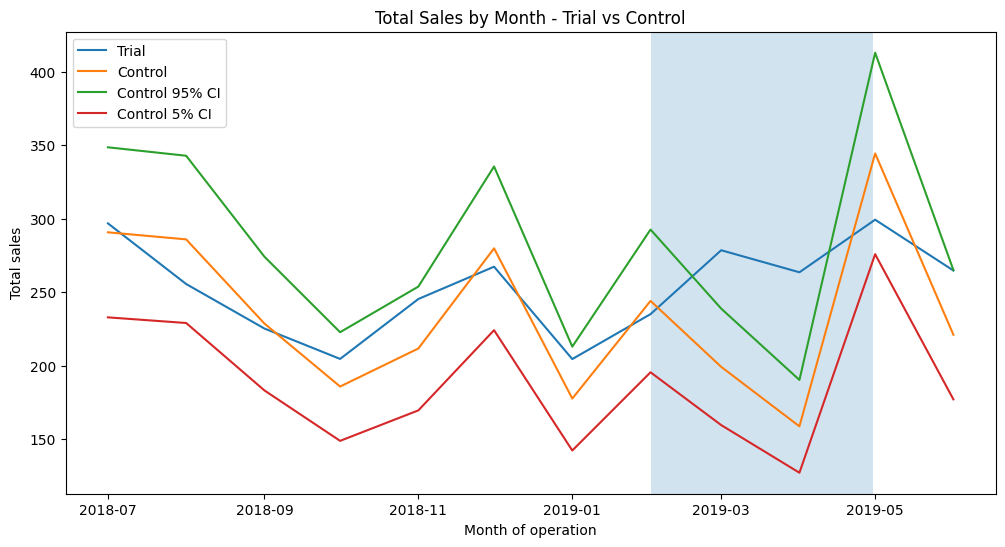

In [18]:
plt.figure(figsize=(12,6))

for label in trialAssessment["Store_type"].unique():
    subset = trialAssessment[trialAssessment["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2
)

plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.title("Total Sales by Month - Trial vs Control")
plt.legend()
plt.show()

# <b style="color:red"> Checking if sales increase because more people visited or because customer bought more per visit </b>

# Computing scaling factors { Customers }

In [19]:
trial_pre_cust = measureOverTime[
    (measureOverTime["STORE_NBR"] == trial_store) &
    (measureOverTime["YEARMONTH"] < 201902)
]["ncustomers"].sum()

control_pre_cust = measureOverTime[
    (measureOverTime["STORE_NBR"] == control_store) &
    (measureOverTime["YEARMONTH"] < 201902)
]["ncustomers"].sum()

scalingFactorForControlCust = trial_pre_cust / control_pre_cust
scalingFactorForControlCust

np.float64(1.0033557046979866)

# Applying Scaling to control store

In [20]:
measureOverTimeCusts = measureOverTime.copy()

measureOverTimeCusts["Store_type"] = measureOverTimeCusts["STORE_NBR"].apply(
    lambda x: "Trial" if x == trial_store
    else ("Control" if x == control_store else "Other")
)

scaledControlCustomers = measureOverTimeCusts[
    measureOverTimeCusts["STORE_NBR"] == control_store
].copy()

scaledControlCustomers["controlCustomers"] = (
    scaledControlCustomers["ncustomers"] * scalingFactorForControlCust
)
scaledControlCustomers

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,Store_type,controlCustomers
2699,233,201807,290.7,54,51,88,1.058824,1.629630,3.303409,Control,51.171141
2700,233,201808,285.9,50,48,80,1.041667,1.600000,3.573750,Control,48.161074
2701,233,201809,228.6,45,42,70,1.071429,1.555556,3.265714,Control,42.140940
2702,233,201810,185.7,36,35,56,1.028571,1.555556,3.316071,Control,35.117450
2703,233,201811,211.6,41,40,62,1.025000,1.512195,3.412903,Control,40.134228
2704,233,201812,279.8,50,47,75,1.063830,1.500000,3.730667,Control,47.157718
2705,233,201901,177.5,35,35,47,1.000000,1.342857,3.776596,Control,35.117450
2706,233,201902,244.0,47,45,70,1.044444,1.489362,3.485714,Control,45.151007
2707,233,201903,199.1,41,40,59,1.025000,1.439024,3.374576,Control,40.134228
2708,233,201904,158.6,32,30,46,1.066667,1.437500,3.447826,Control,30.100671


# Calculating Percentage Difference & Standard Deviation on pretrial only

In [21]:
trialCustomers = measureOverTimeCusts[
    measureOverTimeCusts["STORE_NBR"] == trial_store
][["YEARMONTH", "ncustomers"]]

percentageDiff = trialCustomers.merge(
    scaledControlCustomers[["YEARMONTH", "controlCustomers"]],
    on="YEARMONTH"
)

percentageDiff["percentageDiff"] = (
    (percentageDiff["ncustomers"] - percentageDiff["controlCustomers"])
    / percentageDiff["controlCustomers"]
)
stdDev = percentageDiff[
    percentageDiff["YEARMONTH"] < 201902
]["percentageDiff"].std()


print(stdDev);
percentageDiff

0.02743996009077893


,YEARMONTH,ncustomers,controlCustomers,percentageDiff
0,201807,51,51.171141,-0.003344
1,201808,47,48.161074,-0.024108
2,201809,42,42.140940,-0.003344
3,201810,37,35.117450,0.053607
4,201811,41,40.134228,0.021572
5,201812,46,47.157718,-0.024550
6,201901,35,35.117450,-0.003344
7,201902,45,45.151007,-0.003344
8,201903,50,40.134228,0.245819
9,201904,47,30.100671,0.561427


# Creating 95% Confidence Brands

In [22]:
degreesOfFreedom = 6 

pastCustomers = measureOverTimeCusts[
    measureOverTimeCusts["Store_type"].isin(["Trial", "Control"])
].copy()

pastCustomers["TransactionMonth"] = pd.to_datetime(
    pastCustomers["YEARMONTH"].astype(str) + "01",
    format="%Y%m%d"
)

control_data = pastCustomers[
    pastCustomers["Store_type"] == "Control"
].copy()

control_95 = control_data.copy()
control_95["ncustomers"] = control_95["ncustomers"] * (1 + 2 * stdDev)
control_95["Store_type"] = "Control 95% CI"

control_5 = control_data.copy()
control_5["ncustomers"] = control_5["ncustomers"] * (1 - 2 * stdDev)
control_5["Store_type"] = "Control 5% CI"

trialAssessment = pd.concat([pastCustomers, control_95, control_5])
trialAssessment

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,Store_type,TransactionMonth
880,77,201807,296.8,55,51.000000,84,1.078431,1.527273,3.533333,Trial,2018-07-01
881,77,201808,255.5,48,47.000000,74,1.021277,1.541667,3.452703,Trial,2018-08-01
882,77,201809,225.2,44,42.000000,70,1.047619,1.590909,3.217143,Trial,2018-09-01
883,77,201810,204.5,38,37.000000,52,1.027027,1.368421,3.932692,Trial,2018-10-01
884,77,201811,245.3,44,41.000000,67,1.073171,1.522727,3.661194,Trial,2018-11-01
885,77,201812,267.3,48,46.000000,72,1.043478,1.500000,3.712500,Trial,2018-12-01
886,77,201901,204.4,39,35.000000,65,1.114286,1.666667,3.144615,Trial,2019-01-01
887,77,201902,235.0,45,45.000000,74,1.000000,1.644444,3.175676,Trial,2019-02-01
888,77,201903,278.5,55,50.000000,82,1.100000,1.490909,3.396341,Trial,2019-03-01
889,77,201904,263.5,48,47.000000,78,1.021277,1.625000,3.378205,Trial,2019-04-01


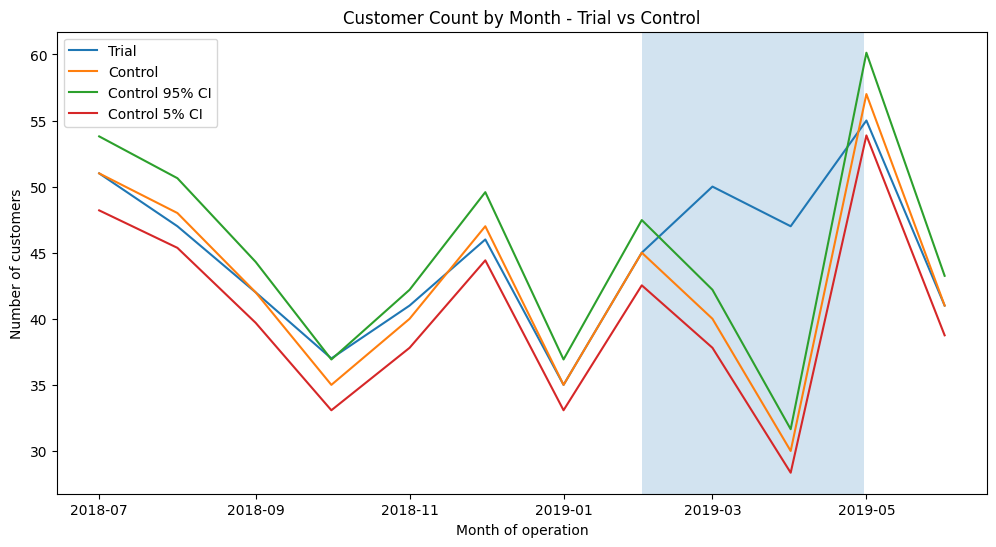

In [23]:
plt.figure(figsize=(12,6))

for label in trialAssessment["Store_type"].unique():
    subset = trialAssessment[trialAssessment["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2
)

plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.title("Customer Count by Month - Trial vs Control")
plt.legend()
plt.show()

### Hence, in Trial period (Feb–Apr), Sales/customers increased significantly & After trial numbers revert, indicating the effect was driven by the trial itself, not seasonal trends

# <b style="color:Blue"> For trial store 86 </b>

# Calculating and combining Correlation & Magnitude

In [24]:
trial_store = 86;

#Correlation
corr_nSales = calculate_correlation(preTrialMeasures,"totSales",trial_store) ;
corr_nCustomers = calculate_correlation(preTrialMeasures,"ncustomers",trial_store) ;

#Magnitude
magnitude_nSales = calculate_magnitude_distance(preTrialMeasures,"totSales",trial_store) ;
magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures,"ncustomers",trial_store) ;

corr_weight = 0.5

score_nSales = (corr_nSales.merge(magnitude_nSales, on=["Store1", "Store2"]));

score_nSales["scoreNSales"] = (corr_weight * score_nSales["corr_measure"] + (1 - corr_weight) * score_nSales["mag_measure"]);

score_nCustomers = (corr_nCustomers.merge(magnitude_nCustomers, on=["Store1", "Store2"]));

score_nCustomers["scoreNCust"] = (corr_weight * score_nCustomers["corr_measure"] +(1 - corr_weight) * score_nCustomers["mag_measure"]);

# Combine Drivers (Simple Average) & Selecting best control store

In [25]:
score_Control = (
    score_nSales[["Store1", "Store2", "scoreNSales"]]
    .merge(
        score_nCustomers[["Store1", "Store2", "scoreNCust"]],
        on=["Store1", "Store2"]
    )
)

score_Control["finalControlScore"] = (
    0.5 * score_Control["scoreNSales"] +
    0.5 * score_Control["scoreNCust"]
)

control_store = (
    score_Control
    .sort_values("finalControlScore", ascending=False)
    .iloc[0]["Store2"]
)

control_store

np.float64(155.0)

# Visual Check of total Sales

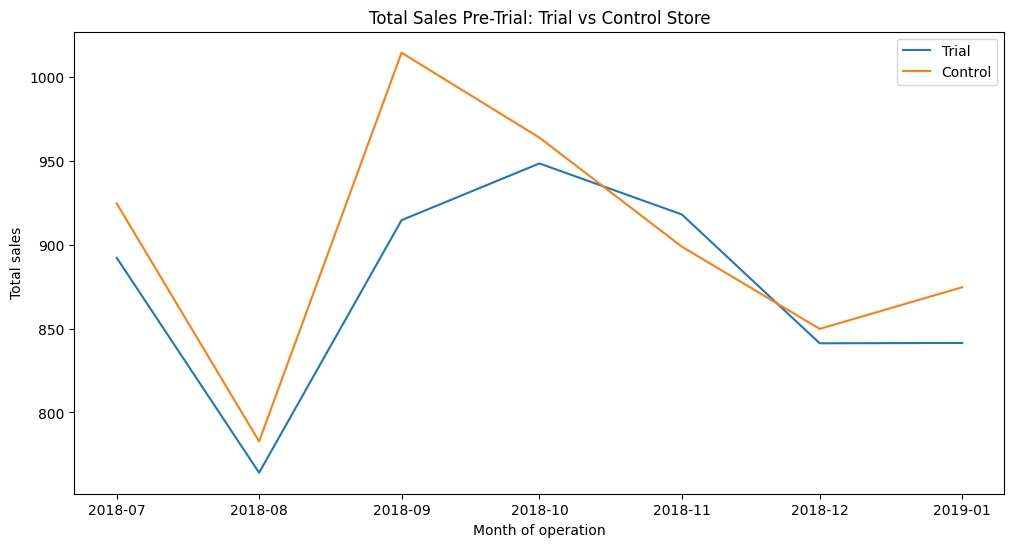

In [26]:
measureOverTimeSales = measureOverTime.copy()

measureOverTimeSales["Store_type"] = measureOverTimeSales["STORE_NBR"].apply(
    lambda x: "Trial" if x == trial_store else ("Control" if x == control_store else "Other")
)

pastSales = measureOverTimeSales.groupby(
    ["YEARMONTH", "Store_type"], as_index=False
)["totSales"].mean()

pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

pastSales = pastSales[pastSales["YEARMONTH"] < 201902]


plt.figure(figsize=(12,6))
for label in ["Trial", "Control"]:
    subset = pastSales[pastSales["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"], label=label)

plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.title("Total Sales Pre-Trial: Trial vs Control Store")
plt.legend()
plt.show()

###  Great, sales are trending in a similar way.

# Visual check of no of customers

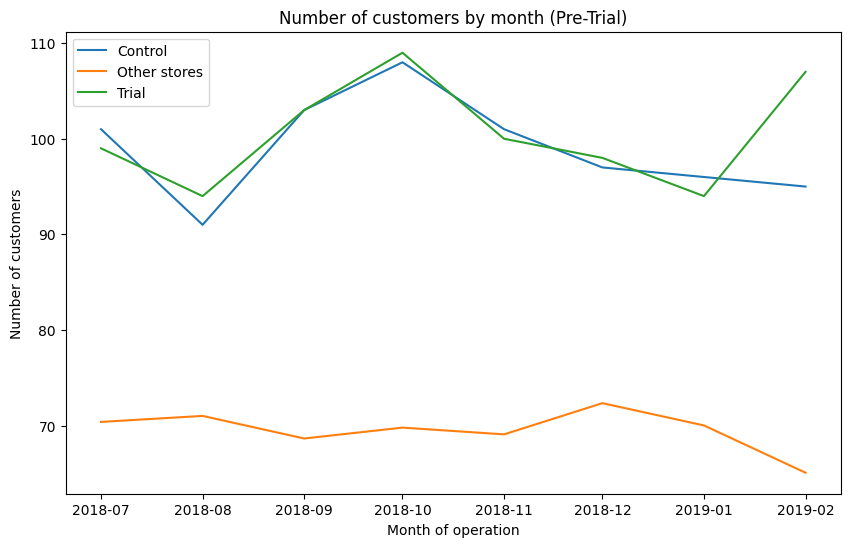

In [27]:
measureOverTimeCusts = measureOverTime.copy()

measureOverTimeCusts["Store_type"] = np.where(
    measureOverTimeCusts["STORE_NBR"] == trial_store, "Trial",
    np.where(measureOverTimeCusts["STORE_NBR"] == control_store, "Control", "Other stores")
)

pastCustomers = measureOverTimeCusts.groupby(["YEARMONTH", "Store_type"])["ncustomers"].mean().reset_index()

pastCustomers["TransactionMonth"] = pd.to_datetime(pastCustomers["YEARMONTH"].astype(str) + "01", format="%Y%m%d")

pastCustomers = pastCustomers[pastCustomers["YEARMONTH"] < 201903]

plt.figure(figsize=(10, 6))
for label in pastCustomers["Store_type"].unique():
    subset = pastCustomers[pastCustomers["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label)
plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.title("Number of customers by month (Pre-Trial)")
plt.legend()
plt.show()

### Good, the trend in number of customers is also similar.

# <b style="color:red"> Checking if sales significantly increase during Feb–Apr 2019</b>

# Computing Scaling Factor {Sales}

In [28]:
scalingFactorForControlSales = (
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == trial_store]["totSales"].sum() /
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == control_store]["totSales"].sum()
)

scaledControlSales = measureOverTime[measureOverTime["STORE_NBR"] == control_store].copy()
scaledControlSales["controlSales"] = scaledControlSales["totSales"] * scalingFactorForControlSales

percentageDiff = (
    measureOverTime[measureOverTime["STORE_NBR"] == trial_store][["YEARMONTH", "totSales"]]
    .merge(scaledControlSales[["YEARMONTH", "controlSales"]], on="YEARMONTH")
)
percentageDiff["percentageDiff"] = (
    (percentageDiff["totSales"] - percentageDiff["controlSales"]) / percentageDiff["controlSales"]
)

stdDev = percentageDiff[percentageDiff["YEARMONTH"] < 201902]["percentageDiff"].std()

degreesOfFreedom = 7

percentageDiff["tValue"] = percentageDiff["percentageDiff"] / stdDev
percentageDiff

,YEARMONTH,totSales,controlSales,percentageDiff,tValue
0,201807,892.20,896.922236,-0.005265,-0.139708
1,201808,764.05,759.269991,0.006296,0.167055
2,201809,914.60,984.034086,-0.070561,-1.872364
3,201810,948.40,934.948790,0.014387,0.381770
4,201811,918.00,871.894555,0.052880,1.403188
5,201812,841.20,824.361363,0.020426,0.542022
6,201901,841.40,848.418979,-0.008273,-0.219529
7,201902,913.20,864.522060,0.056306,1.494114
8,201903,1026.80,780.320405,0.315870,8.381769
9,201904,848.20,819.317024,0.035253,0.935444


# Combine trial assessment with pre-trial, trial, and post-trial data for Total Sales

In [29]:
measureOverTimeSales = measureOverTime.copy()
measureOverTimeSales["TransactionMonth"] = pd.to_datetime(
    measureOverTimeSales["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

trial_sales = measureOverTimeSales[measureOverTimeSales["STORE_NBR"] == trial_store].copy()
trial_sales["Store_type"] = "Trial"

control_sales = measureOverTimeSales[measureOverTimeSales["STORE_NBR"] == control_store].copy()
control_sales["Store_type"] = "Control"

scaled_control_sales = control_sales.copy()
scaled_control_sales["totSales"] = scaled_control_sales["totSales"] * scalingFactorForControlSales
scaled_control_sales["Store_type"] = "Control"

trialAssessmentSales = pd.concat([trial_sales, scaled_control_sales])

control_95_sales = control_sales.copy()
control_95_sales["totSales"] = control_95_sales["totSales"] * scalingFactorForControlSales * (1 + stdDev * 2)
control_95_sales["Store_type"] = "Control 95% CI"

control_5_sales = control_sales.copy()
control_5_sales["totSales"] = control_5_sales["totSales"] * scalingFactorForControlSales * (1 - stdDev * 2)
control_5_sales["Store_type"] = "Control 5% CI"

trialAssessmentSales = pd.concat([trialAssessmentSales, control_95_sales, control_5_sales])
trialAssessmentSales.sort_values(["YEARMONTH", "Store_type"]).head()

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,TransactionMonth,Store_type
1793,155,201807,896.922236,123,101,250,1.217822,2.032520,3.698400,2018-07-01,Control
1793,155,201807,829.320619,123,101,250,1.217822,2.032520,3.698400,2018-07-01,Control 5% CI
1793,155,201807,964.523853,123,101,250,1.217822,2.032520,3.698400,2018-07-01,Control 95% CI
977,86,201807,892.200000,126,99,251,1.272727,1.992063,3.554582,2018-07-01,Trial
1794,155,201808,759.269991,119,91,229,1.307692,1.924370,3.417904,2018-08-01,Control


# Plotting Everything Together

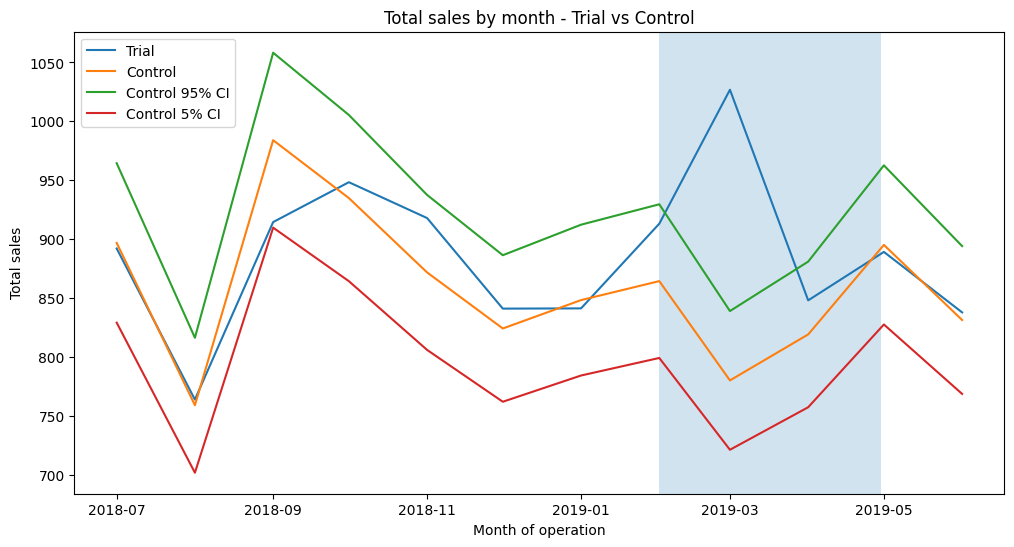

In [30]:
plt.figure(figsize=(12,6))
for label in trialAssessmentSales["Store_type"].unique():
    subset = trialAssessmentSales[trialAssessmentSales["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2
)
plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.title("Total sales by month - Trial vs Control")
plt.legend()
plt.show()

# <b style="color:red"> Checking if sales increase because more people visited or because customer bought more per visit </b>

# Computing Scaling Factor {Customers}

In [31]:
scalingFactorForControlCust = (
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == trial_store]["ncustomers"].sum() /
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == control_store]["ncustomers"].sum()
)

scaledControlCustomers = measureOverTime[measureOverTime["STORE_NBR"] == control_store].copy()
scaledControlCustomers["controlCustomers"] = scaledControlCustomers["ncustomers"] * scalingFactorForControlCust

percentageDiffCust = (
    measureOverTime[measureOverTime["STORE_NBR"] == trial_store][["YEARMONTH", "ncustomers"]]
    .merge(scaledControlCustomers[["YEARMONTH", "controlCustomers"]], on="YEARMONTH")
)
percentageDiffCust["percentageDiff"] = (
    (percentageDiffCust["ncustomers"] - percentageDiffCust["controlCustomers"]) / percentageDiffCust["controlCustomers"]
)

stdDevCust = percentageDiffCust[percentageDiffCust["YEARMONTH"] < 201902]["percentageDiff"].std()

percentageDiffCust["tValue"] = percentageDiffCust["percentageDiff"] / stdDevCust;
percentageDiffCust

,YEARMONTH,ncustomers,controlCustomers,percentageDiff,tValue
0,201807,99,101.0,-0.019802,-1.033550
1,201808,94,91.0,0.032967,1.720691
2,201809,103,103.0,0.000000,0.000000
3,201810,109,108.0,0.009259,0.483281
4,201811,100,101.0,-0.009901,-0.516775
5,201812,98,97.0,0.010309,0.538086
6,201901,94,96.0,-0.020833,-1.087381
7,201902,107,95.0,0.126316,6.592964
8,201903,115,94.0,0.223404,11.660429
9,201904,105,99.0,0.060606,3.163291


# Combine trial assessment with pre-trial, trial, and post-trial data for Number of Customers

In [32]:
measureOverTimeCusts = measureOverTime.copy()
measureOverTimeCusts["TransactionMonth"] = pd.to_datetime(
    measureOverTimeCusts["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

trial_cust = measureOverTimeCusts[measureOverTimeCusts["STORE_NBR"] == trial_store].copy()
trial_cust["Store_type"] = "Trial"

control_cust = measureOverTimeCusts[measureOverTimeCusts["STORE_NBR"] == control_store].copy()
control_cust["Store_type"] = "Control"

scaled_control_cust = control_cust.copy()
scaled_control_cust["ncustomers"] = scaled_control_cust["ncustomers"] * scalingFactorForControlCust
scaled_control_cust["Store_type"] = "Control"

trialAssessmentCust = pd.concat([trial_cust, scaled_control_cust])

control_95_cust = control_cust.copy()
control_95_cust["ncustomers"] = control_95_cust["ncustomers"] * scalingFactorForControlCust * (1 + stdDevCust * 2)
control_95_cust["Store_type"] = "Control 95% CI"

control_5_cust = control_cust.copy()
control_5_cust["ncustomers"] = control_5_cust["ncustomers"] * scalingFactorForControlCust * (1 - stdDevCust * 2)
control_5_cust["Store_type"] = "Control 5% CI"

trialAssessmentCust = pd.concat([trialAssessmentCust, control_95_cust, control_5_cust])
trialAssessmentCust.sort_values(["YEARMONTH", "Store_type"]).head()

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,TransactionMonth,Store_type
1793,155,201807,924.6,123,101.000000,250,1.217822,2.032520,3.698400,2018-07-01,Control
1793,155,201807,924.6,123,97.129846,250,1.217822,2.032520,3.698400,2018-07-01,Control 5% CI
1793,155,201807,924.6,123,104.870154,250,1.217822,2.032520,3.698400,2018-07-01,Control 95% CI
977,86,201807,892.2,126,99.000000,251,1.272727,1.992063,3.554582,2018-07-01,Trial
1794,155,201808,782.7,119,91.000000,229,1.307692,1.924370,3.417904,2018-08-01,Control


# Plotting Everything Together

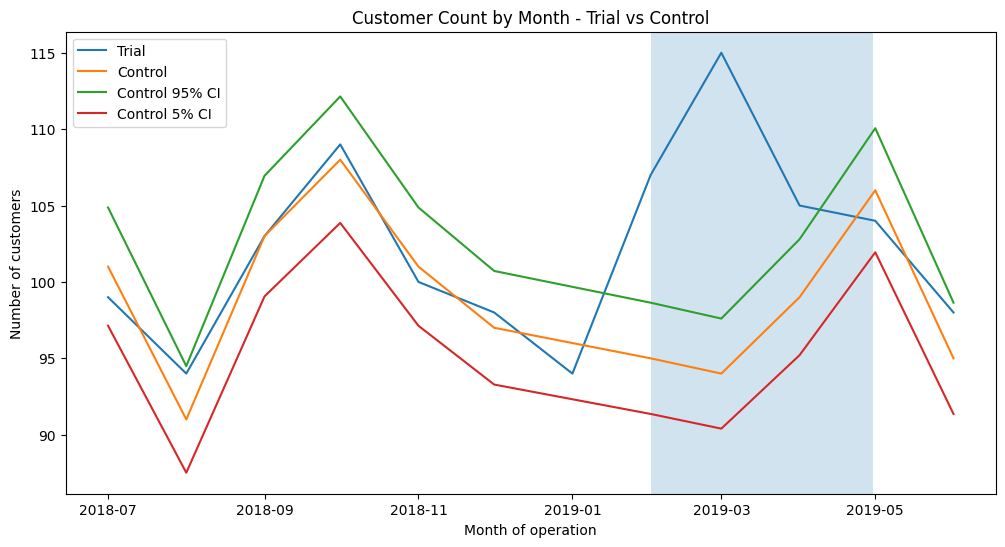

In [33]:
plt.figure(figsize=(12,6))
for label in trialAssessmentCust["Store_type"].unique():
    subset = trialAssessmentCust[trialAssessmentCust["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2
)
plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.title("Customer Count by Month - Trial vs Control")
plt.legend()
plt.show()

### Hence, according to the plots and the way the trial store behaves relative to the scaled control store + confidence intervals, there is a clear and significant uplift during the trial period (Feb–Apr 2019) for store 86 compared to its matched control store 155.

# <b style="color:Blue"> For trial store 88 </b>

# Calculating and combining Correlation & Magnitude

In [34]:
trial_store = 88

# Correlation
corr_nSales    = calculate_correlation(preTrialMeasures, "totSales",    trial_store)
corr_nCustomers = calculate_correlation(preTrialMeasures, "ncustomers", trial_store)

# Magnitude distance
magnitude_nSales    = calculate_magnitude_distance(preTrialMeasures, "totSales",    trial_store)
magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures, "ncustomers", trial_store)

corr_weight = 0.5

# Combine correlation & magnitude 
score_nSales = corr_nSales.merge(magnitude_nSales, on=["Store1", "Store2"])
score_nSales["scoreNSales"] = (
    corr_weight * score_nSales["corr_measure"] +
    (1 - corr_weight) * score_nSales["mag_measure"]
)

score_nCustomers = corr_nCustomers.merge(magnitude_nCustomers, on=["Store1", "Store2"])
score_nCustomers["scoreNCust"] = (
    corr_weight * score_nCustomers["corr_measure"] +
    (1 - corr_weight) * score_nCustomers["mag_measure"]
)
score_nCustomers

,Store1,Store2,corr_measure,mag_measure,scoreNCust
0,88,1,0.305334,0.357143,0.331238
1,88,2,-0.452379,0.285714,-0.083332
2,88,3,0.522884,0.683673,0.603279
3,88,4,-0.361503,0.577922,0.108210
4,88,5,-0.025320,0.558442,0.266561
...,...,...,...,...,...
254,88,268,0.672672,0.630252,0.651462
255,88,269,-0.274781,0.360902,0.043061
256,88,270,-0.103032,0.367965,0.132467
257,88,271,-0.018831,0.655844,0.318507


# Combine Drivers (Simple Average) & Selecting best control store

In [35]:
score_Control = (
    score_nSales[["Store1", "Store2", "scoreNSales"]]
    .merge(
        score_nCustomers[["Store1", "Store2", "scoreNCust"]],
        on=["Store1", "Store2"]
    )
)

score_Control["finalControlScore"] = (
    0.5 * score_Control["scoreNSales"] +
    0.5 * score_Control["scoreNCust"]
)

control_store = (
    score_Control
    .sort_values("finalControlScore", ascending=False)
    .iloc[0]["Store2"]         
)

score_Control.sort_values("finalControlScore", ascending=False)

control_store = 237 ;

# Visual checks on trends based on the drivers – Pre-Trial Total Sales

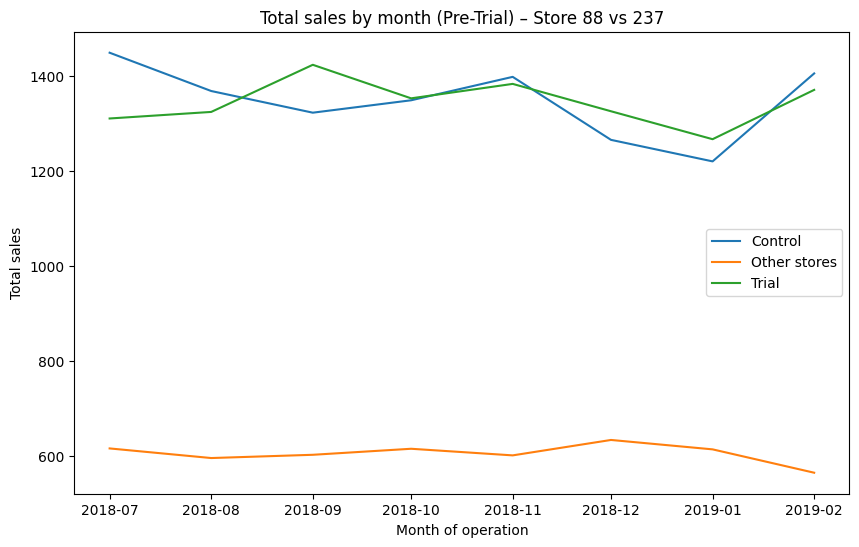

In [36]:
measureOverTimeSales = measureOverTime.copy()

measureOverTimeSales["Store_type"] = np.where(
    measureOverTimeSales["STORE_NBR"] == trial_store, "Trial",
    np.where(measureOverTimeSales["STORE_NBR"] == control_store, "Control", "Other stores")
)

pastSales = measureOverTimeSales.groupby(["YEARMONTH", "Store_type"])["totSales"].mean().reset_index()

pastSales["TransactionMonth"] = pd.to_datetime(
    pastSales["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

pastSales = pastSales[pastSales["YEARMONTH"] < 201903]

plt.figure(figsize=(10, 6))
for label in pastSales["Store_type"].unique():
    subset = pastSales[pastSales["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"], label=label)

plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.title("Total sales by month (Pre-Trial) – Store 88 vs 237")
plt.legend()
plt.show()

### the trial and control stores have similar total sales trends before the trial.

# Visual checks on trends based on the drivers – Pre-Trial Number of Customers

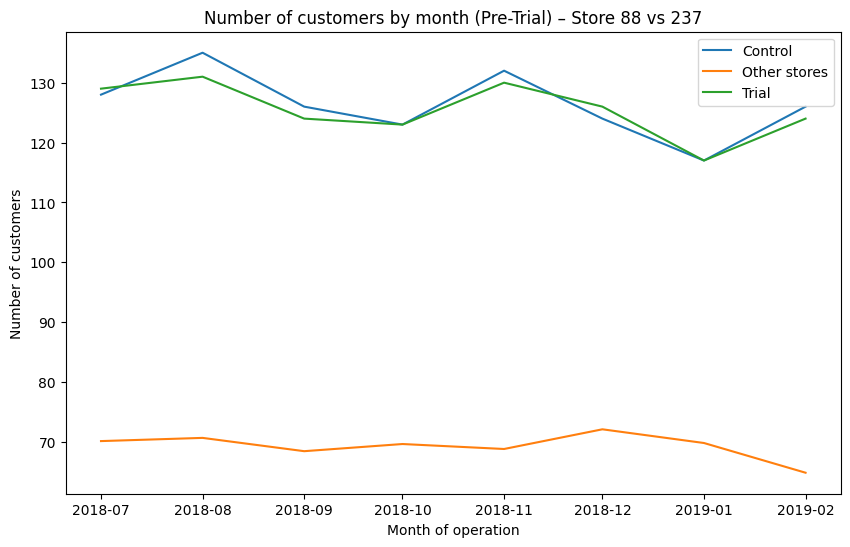

In [37]:
measureOverTimeCusts = measureOverTime.copy()

measureOverTimeCusts["Store_type"] = np.where(
    measureOverTimeCusts["STORE_NBR"] == trial_store, "Trial",
    np.where(measureOverTimeCusts["STORE_NBR"] == control_store, "Control", "Other stores")
)

pastCustomers = measureOverTimeCusts.groupby(["YEARMONTH", "Store_type"])["ncustomers"].mean().reset_index()

pastCustomers["TransactionMonth"] = pd.to_datetime(
    pastCustomers["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

pastCustomers = pastCustomers[pastCustomers["YEARMONTH"] < 201903]

plt.figure(figsize=(10, 6))
for label in pastCustomers["Store_type"].unique():
    subset = pastCustomers[pastCustomers["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label)

plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.title("Number of customers by month (Pre-Trial) – Store 88 vs 237")
plt.legend()
plt.show()

### otal number of customers of the control and trial stores are also similar.

# Calculating Scaling Factors for sale.

In [38]:
scalingFactorForControlSales = (
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == trial_store]["totSales"].sum() /
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == control_store]["totSales"].sum()
)

scaledControlSales = measureOverTime[measureOverTime["STORE_NBR"] == control_store].copy()
scaledControlSales["controlSales"] = scaledControlSales["totSales"] * scalingFactorForControlSales

percentageDiff = (
    measureOverTime[measureOverTime["STORE_NBR"] == trial_store][["YEARMONTH", "totSales"]]
    .merge(scaledControlSales[["YEARMONTH", "controlSales"]], on="YEARMONTH")
)
percentageDiff["percentageDiff"] = (
    (percentageDiff["totSales"] - percentageDiff["controlSales"]) / percentageDiff["controlSales"]
)

stdDev = percentageDiff[percentageDiff["YEARMONTH"] < 201902]["percentageDiff"].std()
percentageDiff.head()

,YEARMONTH,totSales,controlSales,percentageDiff
0,201807,1310.0,1450.657086,-0.096961
1,201808,1323.8,1369.931485,-0.033674
2,201809,1423.0,1324.260425,0.074562
3,201810,1352.4,1350.401097,0.001480
4,201811,1382.8,1399.777923,-0.012129


# Combine trial assessment with pre-trial, trial, and post-trial data for Total Sales

In [39]:
measureOverTimeSales = measureOverTime.copy()
measureOverTimeSales["TransactionMonth"] = pd.to_datetime(
    measureOverTimeSales["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

trial_sales = measureOverTimeSales[measureOverTimeSales["STORE_NBR"] == trial_store].copy()
trial_sales["Store_type"] = "Trial"

control_sales = measureOverTimeSales[measureOverTimeSales["STORE_NBR"] == control_store].copy()
control_sales["Store_type"] = "Control"

scaled_control_sales = control_sales.copy()
scaled_control_sales["totSales"] = scaled_control_sales["totSales"] * scalingFactorForControlSales
scaled_control_sales["Store_type"] = "Control"

trialAssessment = pd.concat([trial_sales, scaled_control_sales])

control_95 = control_sales.copy()
control_95["totSales"] = control_95["totSales"] * scalingFactorForControlSales * (1 + stdDev * 2)
control_95["Store_type"] = "Control 95% CI"

control_5 = control_sales.copy()
control_5["totSales"] = control_5["totSales"] * scalingFactorForControlSales * (1 - stdDev * 2)
control_5["Store_type"] = "Control 5% CI"

trialAssessment = pd.concat([trialAssessment, control_95, control_5])
trialAssessment.head()

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,TransactionMonth,Store_type
1001,88,201807,1310.0,153,129,306,1.186047,2.000000,4.281046,2018-07-01,Trial
1002,88,201808,1323.8,158,131,303,1.206107,1.917722,4.368977,2018-08-01,Trial
1003,88,201809,1423.0,157,124,318,1.266129,2.025478,4.474843,2018-09-01,Trial
1004,88,201810,1352.4,155,123,316,1.260163,2.038710,4.279747,2018-10-01,Trial
1005,88,201811,1382.8,156,130,314,1.200000,2.012821,4.403822,2018-11-01,Trial


# Plotting Everything Together

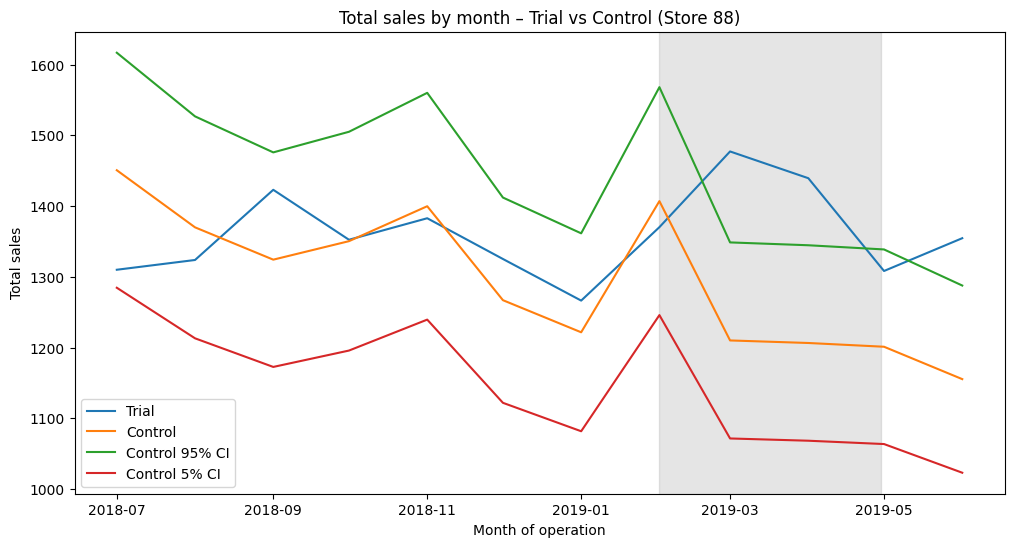

In [40]:
plt.figure(figsize=(12,6))
for label in trialAssessment["Store_type"].unique():
    subset = trialAssessment[trialAssessment["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["totSales"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2, color='gray'
)
plt.xlabel("Month of operation")
plt.ylabel("Total sales")
plt.title("Total sales by month – Trial vs Control (Store 88)")
plt.legend()
plt.show()

# Calculating Scaling Factors for no of customers.

In [41]:
scalingFactorForControlCust = (
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == trial_store]["ncustomers"].sum() /
    preTrialMeasures[preTrialMeasures["STORE_NBR"] == control_store]["ncustomers"].sum()
)

scaledControlCustomers = measureOverTime[measureOverTime["STORE_NBR"] == control_store].copy()
scaledControlCustomers["controlCustomers"] = (
    scaledControlCustomers["ncustomers"] * scalingFactorForControlCust
)

percentageDiffCust = (
    measureOverTime[measureOverTime["STORE_NBR"] == trial_store][["YEARMONTH", "ncustomers"]]
    .merge(scaledControlCustomers[["YEARMONTH", "controlCustomers"]], on="YEARMONTH")
)
percentageDiffCust["percentageDiff"] = (
    (percentageDiffCust["ncustomers"] - percentageDiffCust["controlCustomers"]) /
    percentageDiffCust["controlCustomers"]
)

stdDevCust = percentageDiffCust[percentageDiffCust["YEARMONTH"] < 201902]["percentageDiff"].std()
percentageDiffCust.head()

,YEARMONTH,ncustomers,controlCustomers,percentageDiff
0,201807,129,127.276836,0.013539
1,201808,131,134.237288,-0.024116
2,201809,124,125.288136,-0.010281
3,201810,123,122.305085,0.005682
4,201811,130,131.254237,-0.009556


# Combine trial assessment with pre-trial, trial, and post-trial data for Customers

In [42]:
measureOverTimeCusts = measureOverTime.copy()
measureOverTimeCusts["TransactionMonth"] = pd.to_datetime(
    measureOverTimeCusts["YEARMONTH"].astype(str) + "01", format="%Y%m%d"
)

trial_cust = measureOverTimeCusts[measureOverTimeCusts["STORE_NBR"] == trial_store].copy()
trial_cust["Store_type"] = "Trial"

control_cust = measureOverTimeCusts[measureOverTimeCusts["STORE_NBR"] == control_store].copy()
control_cust["Store_type"] = "Control"

scaled_control_cust = control_cust.copy()
scaled_control_cust["ncustomers"] = scaled_control_cust["ncustomers"] * scalingFactorForControlCust
scaled_control_cust["Store_type"] = "Control"

trialAssessmentCust = pd.concat([trial_cust, scaled_control_cust])

control_95_cust = control_cust.copy()
control_95_cust["ncustomers"] = control_95_cust["ncustomers"] * scalingFactorForControlCust * (1 + stdDevCust * 2)
control_95_cust["Store_type"] = "Control 95% CI"

control_5_cust = control_cust.copy()
control_5_cust["ncustomers"] = control_5_cust["ncustomers"] * scalingFactorForControlCust * (1 - stdDevCust * 2)
control_5_cust["Store_type"] = "Control 5% CI"

trialAssessmentCust = pd.concat([trialAssessmentCust, control_95_cust, control_5_cust])

trialAssessmentCust.head()

,STORE_NBR,YEARMONTH,totSales,ntransactions,ncustomers,totalQty,nTxnPerCust,nChipsPerTxn,avgPricePerUnit,TransactionMonth,Store_type
1001,88,201807,1310.0,153,129.0,306,1.186047,2.000000,4.281046,2018-07-01,Trial
1002,88,201808,1323.8,158,131.0,303,1.206107,1.917722,4.368977,2018-08-01,Trial
1003,88,201809,1423.0,157,124.0,318,1.266129,2.025478,4.474843,2018-09-01,Trial
1004,88,201810,1352.4,155,123.0,316,1.260163,2.038710,4.279747,2018-10-01,Trial
1005,88,201811,1382.8,156,130.0,314,1.200000,2.012821,4.403822,2018-11-01,Trial


# Plotting Everything together

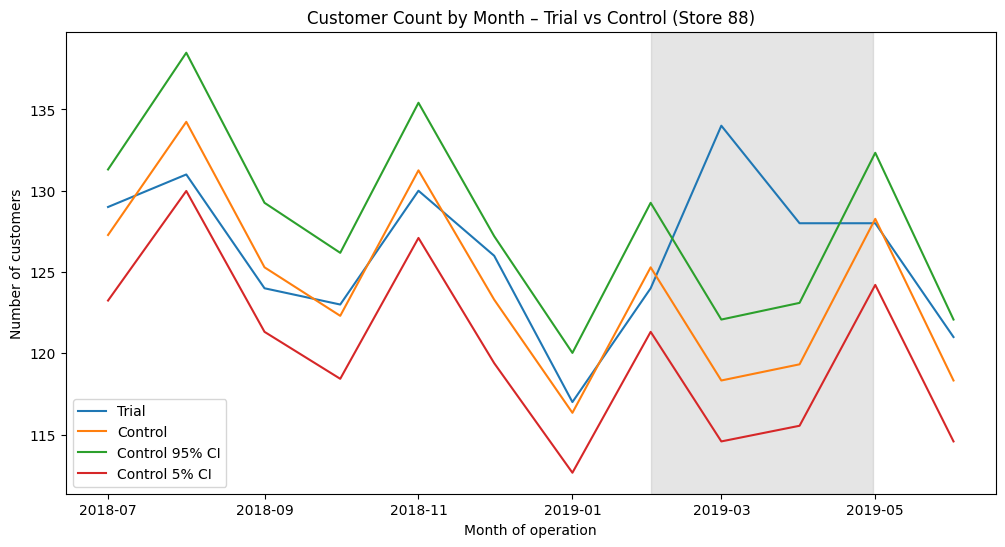

In [43]:
plt.figure(figsize=(12,6))
for label in trialAssessmentCust["Store_type"].unique():
    subset = trialAssessmentCust[trialAssessmentCust["Store_type"] == label]
    plt.plot(subset["TransactionMonth"], subset["ncustomers"], label=label)

plt.axvspan(
    pd.to_datetime("2019-02-01"),
    pd.to_datetime("2019-04-30"),
    alpha=0.2, color='gray'
)
plt.xlabel("Month of operation")
plt.ylabel("Number of customers")
plt.title("Customer Count by Month – Trial vs Control (Store 88)")
plt.legend()
plt.show()

### Total number of customers in the trial period for the trial store is significantly higher than the control store for two out of three months

# Conclusion
We’ve found control stores 233, 155, 237 for trial stores 77, 86 and 88 respectively.

The results for trial stores 77 and 88 during the trial period show a significant

difference in at least two of the three trial months but this is not the case for

trial store 86. We can check with the client if the implementation of the trial was

different in trial store 86 but overall, the trial shows a significant increase in

sales. Now that we have finished our analysis, we can prepare our presentation to

the Category Manager.